In [ ]:
import torch
from torch import nn
from torchvision import transforms
from torchvision import datasets
from torchvision import models
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor, Compose, RandomHorizontalFlip, RandomRotation, RandomCrop, Normalize
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import requests

request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")

with open("helper_functions.py", "wb") as f:
  f.write(request.content)

from helper_functions import accuracy_fn
from tqdm.auto import tqdm

In [ ]:
augmentation = Compose([
    RandomHorizontalFlip(),
    RandomRotation(10),
    RandomCrop(32, padding=4),
    ToTensor(),
    Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
  ])

test_normalize = Compose([
    ToTensor(),
    Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
train_data = datasets.CIFAR100(
    root="data",
    train=True,
    download=True,
    transform=test_normalize
)

test_data = datasets.CIFAR100(
    root="data",
    train=False,
    download=True,
    transform=test_normalize
)

In [ ]:
len(train_data), len(test_data)

(50000, 10000)

In [ ]:
image, label = next(iter(train_data))
image.shape

torch.Size([3, 32, 32])

In [ ]:
train_data.classes[0]

'apple'

In [ ]:
image = image.permute(1,2,0)

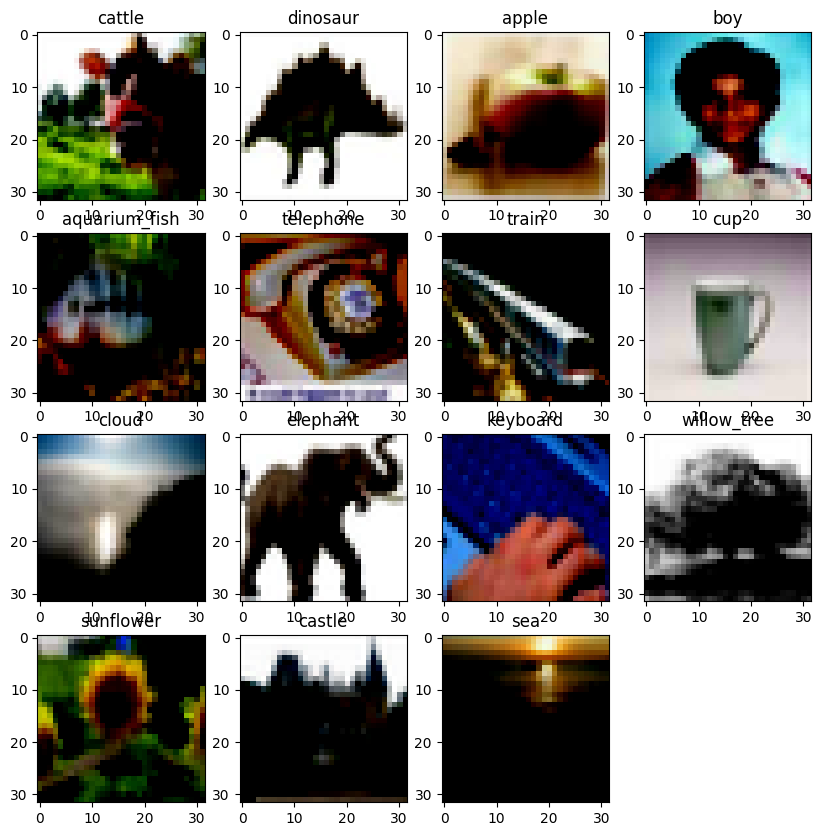

In [ ]:
fig = plt.figure(figsize=(10, 10))
row, col = 4,4
data = iter(train_data)
for i in range(1, row*col):
  X, y = next(data)
  X = X.permute(1,2,0)
  fig.add_subplot(row,col, i)
  plt.imshow(X)
  plt.title(train_data.classes[y])


In [ ]:
train_dataloader = DataLoader(train_data, batch_size=50, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=50, shuffle=True)
len(train_dataloader), len(test_dataloader)

(1000, 200)

In [ ]:
print(f"The Training Dataset has {len(train_dataloader)} batches of size {len(next(iter(train_dataloader))[0])}.")
print(f"The Testing Dataset has {len(test_dataloader)} batches of size {len(next(iter(test_dataloader))[0])}.")

The Training Dataset has 1000 batches of size 50.
The Testing Dataset has 200 batches of size 50.


In [ ]:
def training_loop(model, optimizer, train_dataloader, epoch=10):
  loss_fn = nn.CrossEntropyLoss()
  train_loss_list = []
  test_loss_list = []
  accuracy_list = []


  for i in tqdm(range(epoch)):
    train_loss,test_loss, acu = 0,  0, 0
    model.train()
    for batch, (X,y) in enumerate(train_dataloader):
      X,y = X.to(device), y.to(device)
      y_pred = model(X)
      loss = loss_fn(y_pred, y)
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      train_loss += loss.item()
    model.eval()
    with torch.inference_mode():
      for batch, (X,y) in enumerate(test_dataloader):
        X,y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        test_loss += loss.item()
        acu += accuracy_fn(y, y_pred.argmax(dim=1))
    train_loss = train_loss/len(test_dataloader)
    test_loss = test_loss/len(test_dataloader)
    acu = acu/len(test_dataloader)
    print(f"Epoch #{i+1} | Train Loss: {train_loss:.4f}| Test Loss: {test_loss:.4f}| Accuracy : {acu:.4f}%")
    train_loss_list.append(train_loss)
    test_loss_list.append(test_loss)
    accuracy_list.append(acu)

  return train_loss_list, test_loss_list, accuracy_list


In [ ]:
class ResBlock(nn.Module):
  def __init__(self, input_size: int, out_channel: int, idenity_sample=None, stride=1):
    super().__init__()
    self.Conv1 = nn.Conv2d(in_channels=input_size, out_channels=out_channel, kernel_size=1, stride=1, padding=0)
    self.bn1 = nn.BatchNorm2d(out_channel)
    self.Conv2 = nn.Conv2d(in_channels=out_channel, out_channels=out_channel, kernel_size=3, stride=stride, padding=1)
    self.bn2 = nn.BatchNorm2d(out_channel)
    self.Conv3 = nn.Conv2d(in_channels=out_channel, out_channels=out_channel*4, kernel_size=1, stride=1, padding=0)
    self.bn3 = nn.BatchNorm2d(out_channel*4)
    self.relu = nn.ReLU()
    self.idenity = idenity_sample
  def forward(self, x):
    idenity = x
    x = self.Conv1(x)
    x = self.bn1(x)
    x = self.relu(x)
    x = self.Conv2(x)
    x = self.bn2(x)
    x = self.relu(x)
    x = self.Conv3(x)
    x = self.bn3(x)
    if self.idenity is not None:
      idenity = self.idenity(idenity)

    x += idenity
    x = self.relu(x)
    return x
# Resnet 18 had 3,4,6,3 blocks..
class ResNet(nn.Module):
  def __init__(self, block, image_channels, num_class=100):
    super(ResNet, self).__init__()
    self.in_channels=64
    self.seq1 = nn.Sequential(
      nn.Conv2d(3, 64, kernel_size=3, stride=1,padding=1),
      nn.BatchNorm2d(self.in_channels),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
    )

    self.layer1 = self.make_layer(block, 3, 64, 1)
    self.layer2 = self.make_layer(block, 4, 128, 2)
    self.layer3 = self.make_layer(block, 6, 256, 2)
    self.layer4 = self.make_layer(block, 3, 512, 2)
    self.seq2 = nn.Sequential(
      nn.AdaptiveAvgPool2d((1,1)),
      nn.Flatten(),
      nn.Linear(512*4, num_class)
    )


  def forward(self, x):
    x = self.seq1(x)
    x = self.layer1(x)
    x = self.layer2(x)
    x = self.layer3(x)
    x = self.layer4(x)
    x = self.seq2(x)

    return x


  def make_layer(self, block, num_blocks, out_channels, stride):
    idenity_downsamp = None
    layers = []

    if stride != 1 or self.in_channels != out_channels * 4:
      idenity_downsamp = nn.Sequential(nn.Conv2d(self.in_channels, out_channels=out_channels*4, kernel_size=1, stride=stride),
                                       nn.BatchNorm2d(out_channels*4))
    layers.append(block(self.in_channels, out_channels, idenity_downsamp, stride))
    self.in_channels = out_channels*4
    for i in range(num_blocks-1):
      layers.append(block(self.in_channels, out_channels))

    return nn.Sequential(*layers)



In [ ]:
ResNet = ResNet(ResBlock, image_channels=3).to(device)
optim = torch.optim.SGD(ResNet.parameters(), lr=0.1)
train_loss1, test_loss1, acu1 = training_loop(ResNet, optim, train_dataloader, epoch=10)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch #1 | Train Loss: 20.0965| Test Loss: 3.8234| Accuracy : 15.9700%
Epoch #2 | Train Loss: 15.7866| Test Loss: 3.0126| Accuracy : 26.3500%
Epoch #3 | Train Loss: 13.3246| Test Loss: 3.0615| Accuracy : 34.2800%
Epoch #4 | Train Loss: 11.3142| Test Loss: 2.8288| Accuracy : 39.1400%
Epoch #5 | Train Loss: 9.5598| Test Loss: 2.4125| Accuracy : 41.5100%
Epoch #6 | Train Loss: 7.9698| Test Loss: 2.8135| Accuracy : 42.6300%
Epoch #7 | Train Loss: 6.3661| Test Loss: 2.7992| Accuracy : 42.1600%
Epoch #8 | Train Loss: 5.1602| Test Loss: 2.5002| Accuracy : 42.8400%
Epoch #9 | Train Loss: 3.9169| Test Loss: 2.5508| Accuracy : 44.9900%
Epoch #10 | Train Loss: 2.5088| Test Loss: 3.1026| Accuracy : 44.4700%


In [ ]:
FEmodel = models.resnet18(pretrained=True)
for param in FEmodel.parameters():
  param.requires_grad = False
FEmodel.conv1 =  nn.Conv2d(in_channels=3, out_channels=64, kernel_size=1, stride=1, padding=0)
FEmodel.fc = nn.Linear(in_features=512, out_features=100)
FEmodel.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(1, 1), stride=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, 

In [ ]:
FEoptim = torch.optim.SGD(FEmodel.parameters(), lr=0.01)
train_loss2, test_loss2, acu2 = training_loop(FEmodel, FEoptim, train_dataloader, epoch=10)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch #1 | Train Loss: 21.1590| Test Loss: 3.8865| Accuracy : 13.6400%
Epoch #2 | Train Loss: 18.6262| Test Loss: 3.6859| Accuracy : 17.1800%
Epoch #3 | Train Loss: 17.7292| Test Loss: 3.5884| Accuracy : 18.5300%
Epoch #4 | Train Loss: 17.2226| Test Loss: 3.5283| Accuracy : 19.2400%
Epoch #5 | Train Loss: 16.8917| Test Loss: 3.5122| Accuracy : 19.4800%
Epoch #6 | Train Loss: 16.6749| Test Loss: 3.4769| Accuracy : 19.8700%
Epoch #7 | Train Loss: 16.4848| Test Loss: 3.4631| Accuracy : 20.2100%
Epoch #8 | Train Loss: 16.3724| Test Loss: 3.4784| Accuracy : 19.9600%
Epoch #9 | Train Loss: 16.2207| Test Loss: 3.4556| Accuracy : 20.4500%
Epoch #10 | Train Loss: 16.1045| Test Loss: 3.4358| Accuracy : 20.6600%


In [ ]:
FTmodel = models.resnet18(pretrained=True)
FTmodel.conv1 =  nn.Conv2d(in_channels=3, out_channels=64, kernel_size=1, stride=1, padding=0)
FTmodel.fc = nn.Linear(in_features=512, out_features=100)
FTmodel.to(device)
FToptim = torch.optim.SGD(FTmodel.parameters(), lr=0.01)
train_loss3, test_loss3, acu3 = training_loop(FTmodel, FToptim, train_dataloader, epoch=10)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch #1 | Train Loss: 17.1841| Test Loss: 2.6596| Accuracy : 32.3400%
Epoch #2 | Train Loss: 11.7738| Test Loss: 2.2215| Accuracy : 42.0200%
Epoch #3 | Train Loss: 9.2822| Test Loss: 2.0282| Accuracy : 46.3200%
Epoch #4 | Train Loss: 7.4952| Test Loss: 1.9437| Accuracy : 49.0200%
Epoch #5 | Train Loss: 5.9645| Test Loss: 1.9472| Accuracy : 49.8300%
Epoch #6 | Train Loss: 4.5697| Test Loss: 1.9544| Accuracy : 50.4100%
Epoch #7 | Train Loss: 3.3094| Test Loss: 2.0335| Accuracy : 49.9600%
Epoch #8 | Train Loss: 2.2628| Test Loss: 2.1226| Accuracy : 49.3100%
Epoch #9 | Train Loss: 1.4352| Test Loss: 2.1885| Accuracy : 50.5100%
Epoch #10 | Train Loss: 0.9054| Test Loss: 2.2275| Accuracy : 50.4700%


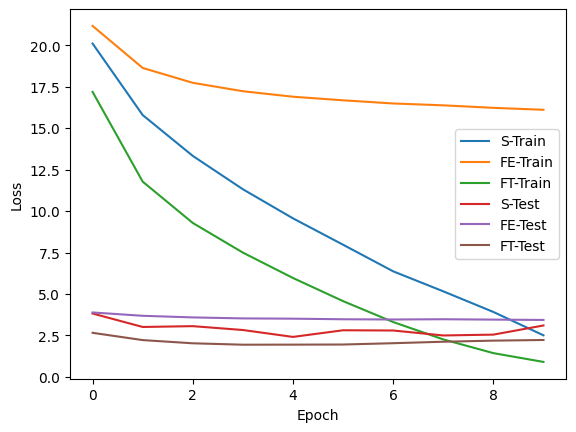

In [ ]:
plt.plot(train_loss1, label = "S-Train") # As in Strach Train Loss
plt.plot(train_loss2, label = "FE-Train") # As in Feature Extraction Train Loss
plt.plot(train_loss3, label = "FT-Train") # As in Fine Tuning Train Loss
plt.plot(test_loss1, label = "S-Test")
plt.plot(test_loss2, label = "FE-Test")
plt.plot(test_loss3, label = "FT-Test")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


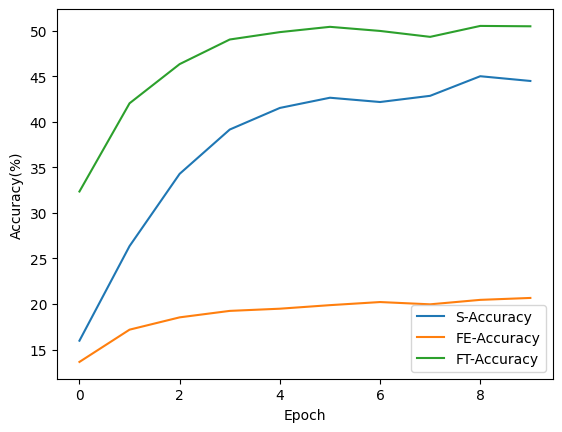

In [ ]:
plt.plot(acu1, label="S-Accuracy")
plt.plot(acu2, label="FE-Accuracy")
plt.plot(acu3, label="FT-Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy(%)")
plt.legend()
plt.show()

Fine Tuned Model worked far better than than the Model made from Strach or the Feature Extracted model.

How to improve the model:
* Chose a better Resnet Model like Resnet34 or Resnet50
* Train for more epochs
* Add Data Augmentation onto the dataset